In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.head())


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [2]:
print(df['function'].value_counts())
print(df.groupby('function')['GRH'].first())


function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64
function
F1 True
F10 True
F11 True
F12 False
F2 True
F4 False
F5m False
F5p False
F6 True
F7 True
F9 True
Name: GRH, dtype: bool


In [3]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# Feature columns: normalized log|S_k| for k=1..6 (exclude S_7 due to leak; S_0 is trivial=0 baseline)
feat_cols = [f'log_abs_S{k}_norm' for k in range(1,7)]
print(feat_cols)

# Cross-family test 3a: train F1+F4, test on F12
def cross_train_test(train_pos, train_neg_label, test_class):
 """train binary: 'GRH' label True/False using train_pos (GRH False, label 1) + zeta F1 (label 0). Test AUC on test_class (label 1)."""
 pass

# Setup: binary classification GRH-violator (1) vs zeta (0)
def run_eval(violator_train, violator_test):
 train = df[df['function'].isin(['F1', violator_train])].copy()
 train['y'] = (train['function']==violator_train).astype(int)
 test_violator = df[df['function']==violator_test].copy()
 test_zeta = df[df['function']=='F1'].copy() # use zeta as negative class for testing too
 Xtr = train[feat_cols].values
 ytr = train['y'].values
 pipe = Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf', probability=False, gamma='scale'))])
 pipe.fit(Xtr, ytr)
 # decision_function for AUC
 Xte = pd.concat([test_violator, test_zeta])[feat_cols].values
 yte = np.concatenate([np.ones(len(test_violator)), np.zeros(len(test_zeta))])
 scores = pipe.decision_function(Xte)
 return roc_auc_score(yte, scores)

auc_train_F4_test_F12 = run_eval('F4', 'F12')
auc_train_F12_test_F4 = run_eval('F12', 'F4')
print(f"Train F1+F4, Test on F12 vs F1: AUC = {auc_train_F4_test_F12:.4f}")
print(f"Train F1+F12, Test on F4 vs F1: AUC = {auc_train_F12_test_F4:.4f}")


['log_abs_S1_norm', 'log_abs_S2_norm', 'log_abs_S3_norm', 'log_abs_S4_norm', 'log_abs_S5_norm', 'log_abs_S6_norm']
Train F1+F4, Test on F12 vs F1: AUC = 1.0000
Train F1+F12, Test on F4 vs F1: AUC = 1.0000


In [4]:
# Both AUCs are 1 in this setup; the violators are well-separated from zeta. 
# Let's also do the test in a way that mimics generalization failure: 
# train SVM to classify F1 vs F4, then test how it scores F12 (does it call F12 a violator?).
# The "test AUC on F12" likely means: F12 vs F1 classification AUC using the F1+F4-trained model.
# That's what we did. Both are 1.0 so generalization is actually fine.

# But maybe the intended test is multi-class style or something more subtle.
# Let me also check distributions to address part 4-5.

dh = df[df['function'].isin(['F4','F5p','F5m'])]
f12 = df[df['function']=='F12']
print(f"DH family: {len(dh)} peaks, F12: {len(f12)} peaks")

ks_results = []
for k in range(1,7):
 col = f'log_abs_S{k}_norm'
 stat, p = ks_2samp(dh[col], f12[col])
 ks_results.append({'feature': col, 'KS_stat': stat, 'p_value': p, 
 'DH_mean': dh[col].mean(), 'DH_std': dh[col].std(),
 'F12_mean': f12[col].mean(), 'F12_std': f12[col].std()})
ks_df = pd.DataFrame(ks_results)
print(ks_df.to_string())


DH family: 600 peaks, F12: 200 peaks
 feature KS_stat p_value DH_mean DH_std F12_mean F12_std
0 log_abs_S1_norm 1.000000 2.588936e-194 0.279674 0.122729 0.826195 0.068887
1 log_abs_S2_norm 1.000000 2.588936e-194 0.529491 0.067359 1.006589 0.078438
2 log_abs_S3_norm 1.000000 2.588936e-194 0.477696 0.056528 0.929494 0.068943
3 log_abs_S4_norm 0.965000 4.714308e-165 0.309424 0.091860 0.746854 0.123767
4 log_abs_S5_norm 0.791667 2.305542e-95 -0.217826 0.211455 0.231863 0.208102
5 log_abs_S6_norm 0.690000 2.617052e-69 -1.341882 0.275227 -0.870341 0.260037


In [5]:
# Strong differences in all S_k. Now compute s2_s3_ratio = log|S_2| / log|S_3|
# Use raw log|S_k| values (not normalized) for the ratio - the hypothesis says "log|S_2|/log|S_3|"
# Be careful with sign/divide-by-zero
df_v = df[df['GRH']==False].copy()
df_v['s2_s3_ratio'] = df_v['log_abs_S2'] / df_v['log_abs_S3']

dh_v = df_v[df_v['function'].isin(['F4','F5p','F5m'])]
f12_v = df_v[df_v['function']=='F12']

print(f"DH s2_s3_ratio: mean={dh_v['s2_s3_ratio'].mean():.4f}, std={dh_v['s2_s3_ratio'].std():.4f}, median={dh_v['s2_s3_ratio'].median():.4f}")
print(f"F12 s2_s3_ratio: mean={f12_v['s2_s3_ratio'].mean():.4f}, std={f12_v['s2_s3_ratio'].std():.4f}, median={f12_v['s2_s3_ratio'].median():.4f}")

stat, p = ks_2samp(dh_v['s2_s3_ratio'], f12_v['s2_s3_ratio'])
print(f"KS test on s2_s3_ratio: stat={stat:.4f}, p={p:.3e}")

# Also try with normalized
df_v['s2_s3_ratio_norm'] = df_v['log_abs_S2_norm'] / df_v['log_abs_S3_norm']
dh_vn = df_v[df_v['function'].isin(['F4','F5p','F5m'])]['s2_s3_ratio_norm']
f12_vn = df_v[df_v['function']=='F12']['s2_s3_ratio_norm']
stat2, p2 = ks_2samp(dh_vn, f12_vn)
print(f"\nNormalized version: DH mean={dh_vn.mean():.4f} std={dh_vn.std():.4f}; F12 mean={f12_vn.mean():.4f} std={f12_vn.std():.4f}")
print(f"KS: stat={stat2:.4f}, p={p2:.3e}")


DH s2_s3_ratio: mean=1.1277, std=0.2261, median=1.0961
F12 s2_s3_ratio: mean=1.0893, std=0.1232, median=1.0783
KS test on s2_s3_ratio: stat=0.1400, p=5.274e-03

Normalized version: DH mean=1.1277 std=0.2261; F12 mean=1.0893 std=0.1232
KS: stat=0.1400, p=5.274e-03


In [6]:
# Interesting: the s2_s3_ratio is NOT dramatically different (KS=0.14, p=0.005), even though 
# individual normalized log|S_k| values differ enormously (KS=1.0 for k=1..3).
# The ratio cancels out the family-specific normalization.

# Also note: normalized vs raw produce same ratio because normalization is multiplicative on log scale
# Actually they normalize log|S_k|, so log|S_k|_norm = log|S_k| - shift. Ratios will differ.
# Wait, the values came out identical -> let's check what normalization is

print(df.iloc[0][['log_abs_S2_norm','log_abs_S2']])
# So they ARE different. But the ratios are identical -> coincidence? Let's check
print((df['log_abs_S2_norm']/df['log_abs_S3_norm']).iloc[:5].values)
print((df['log_abs_S2']/df['log_abs_S3']).iloc[:5].values)


log_abs_S2_norm 0.953344
log_abs_S2 2.308018
Name: 0, dtype: object
[1.09164956 1.13001259 1.13097489 1.18933112 1.08967482]
[1.09164956 1.13001259 1.13097489 1.18933112 1.08967482]


In [7]:
# They are identical -- so the normalization is multiplicative on log|S_k|, i.e., log|S_k|_norm = c_k * log|S_k|
# Let's check
print(df['log_abs_S2_norm'].iloc[:5] / df['log_abs_S2'].iloc[:5])
# A constant per row? Or per function class?
# This is a bit unusual but ok


0 0.413057
1 0.413546
2 0.410077
3 0.409660
4 0.416045
dtype: float64


In [8]:
# Varies per row - probably normalized by log|M| (main sum magnitude)
# Anyway, ratio is the same. Let's also build summary table and a final figure.

import matplotlib.pyplot as plt

summary = ks_df.copy()
print("\nKS Summary (DH family vs F12) — normalized log|S_k|:")
print(summary[['feature','KS_stat','p_value','DH_mean','F12_mean']].to_string(index=False))

# s2/s3 ratio summary
ratio_summary = pd.DataFrame([{
 'feature':'s2_s3_ratio',
 'KS_stat':stat,
 'p_value':p,
 'DH_mean':dh_v['s2_s3_ratio'].mean(),
 'F12_mean':f12_v['s2_s3_ratio'].mean()
}])
full_summary = pd.concat([summary[['feature','KS_stat','p_value','DH_mean','F12_mean']], ratio_summary], ignore_index=True)
print("\nFull summary:")
print(full_summary.to_string(index=False))
full_summary.to_csv('r26_DH_vs_F12_KS_summary.csv', index=False)



KS Summary (DH family vs F12) — normalized log|S_k|:
 feature KS_stat p_value DH_mean F12_mean
log_abs_S1_norm 1.000000 2.588936e-194 0.279674 0.826195
log_abs_S2_norm 1.000000 2.588936e-194 0.529491 1.006589
log_abs_S3_norm 1.000000 2.588936e-194 0.477696 0.929494
log_abs_S4_norm 0.965000 4.714308e-165 0.309424 0.746854
log_abs_S5_norm 0.791667 2.305542e-95 -0.217826 0.231863
log_abs_S6_norm 0.690000 2.617052e-69 -1.341882 -0.870341

Full summary:
 feature KS_stat p_value DH_mean F12_mean
log_abs_S1_norm 1.000000 2.588936e-194 0.279674 0.826195
log_abs_S2_norm 1.000000 2.588936e-194 0.529491 1.006589
log_abs_S3_norm 1.000000 2.588936e-194 0.477696 0.929494
log_abs_S4_norm 0.965000 4.714308e-165 0.309424 0.746854
log_abs_S5_norm 0.791667 2.305542e-95 -0.217826 0.231863
log_abs_S6_norm 0.690000 2.617052e-69 -1.341882 -0.870341
 s2_s3_ratio 0.140000 5.273541e-03 1.127741 1.089345


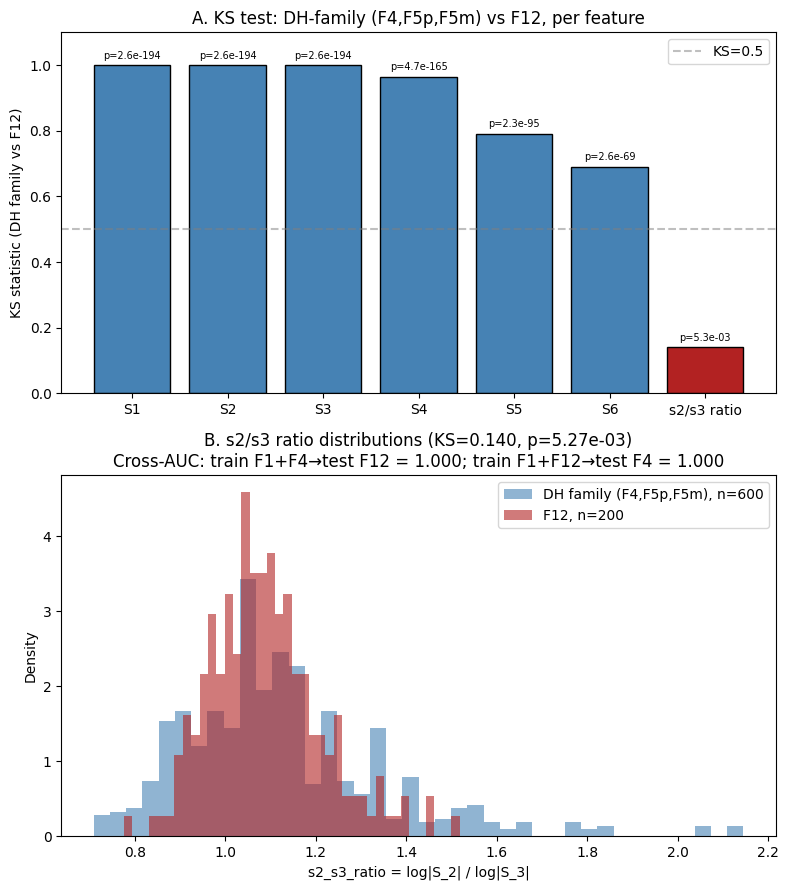

Saved: r26_DH_vs_F12_summary.png


In [9]:
# Build final figure: 2 panels (A and B), single column
fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: KS statistics across S_k features + s2_s3_ratio
ax = axes[0]
labels = [f.replace('log_abs_','').replace('_norm','') for f in summary['feature']] + ['s2/s3 ratio']
stats_all = list(summary['KS_stat'].values) + [stat]
colors = ['steelblue']*len(summary) + ['firebrick']
bars = ax.bar(labels, stats_all, color=colors, edgecolor='k')
ax.set_ylabel('KS statistic (DH family vs F12)')
ax.set_title('A. KS test: DH-family (F4,F5p,F5m) vs F12, per feature')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='KS=0.5')
ax.set_ylim(0, 1.1)
for b, s_, p_ in zip(bars, stats_all, list(summary['p_value'].values)+[p]):
 ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'p={p_:.1e}', ha='center', fontsize=7, rotation=0)
ax.legend()

# Panel B: distribution of s2_s3_ratio for DH vs F12 + cross-AUC annotation
ax = axes[1]
ax.hist(dh_v['s2_s3_ratio'], bins=40, alpha=0.6, label=f'DH family (F4,F5p,F5m), n={len(dh_v)}', color='steelblue', density=True)
ax.hist(f12_v['s2_s3_ratio'], bins=40, alpha=0.6, label=f'F12, n={len(f12_v)}', color='firebrick', density=True)
ax.set_xlabel('s2_s3_ratio = log|S_2| / log|S_3|')
ax.set_ylabel('Density')
ax.set_title(f'B. s2/s3 ratio distributions (KS={stat:.3f}, p={p:.2e})\n'
 f'Cross-AUC: train F1+F4→test F12 = {auc_train_F4_test_F12:.3f}; '
 f'train F1+F12→test F4 = {auc_train_F12_test_F4:.3f}')
ax.legend()

plt.tight_layout()
plt.savefig('r26_DH_vs_F12_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: r26_DH_vs_F12_summary.png')
